# Prediksi Persetujuan Pinjaman Menggunakan Data Demografi dan Finansial dengan Metode Machine Learning





### Sumber Dataset


Dataset yang digunakan berasal dari Kaggle, yaitu platform yang menyediakan berbagai dataset untuk pembelajaran dan penelitian di bidang data science dan machine learning.

Dataset ini berisi data calon peminjam dengan target LoanApproved, yang digunakan untuk memprediksi apakah pinjaman disetujui atau tidak disetujui.

# 1. Data Understanding

Pada tahap Data Understanding, dilakukan pemahaman awal terhadap dataset yang digunakan. Proses ini meliputi melihat beberapa data pertama menggunakan head(), mengetahui informasi dataset seperti jumlah dan tipe data melalui info(), serta melihat statistik data menggunakan describe(). Selain itu, dilakukan pengecekan terhadap missing value dengan isnull().sum() dan analisis distribusi target menggunakan value_counts(). Tahap ini bertujuan untuk memahami struktur dan kondisi data sebelum dilakukan proses pengolahan lebih lanjut.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# Load dataset
df = pd.read_csv("loan_risk_prediction_dataset.csv")

# Melihat data
df.head()

# Informasi dataset
df.info()

# Statistik
df.describe()

# Missing value
df.isnull().sum()

# Distribusi target
print(df["LoanApproved"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB
LoanApproved
0    3849
1    1151
Name: count, dtype: int64


# 2. Data Preprocessing

Pada tahap Data Preprocessing, dilakukan proses pembersihan dan persiapan data agar siap digunakan dalam pemodelan. Pertama, dilakukan penanganan missing value, di mana data numerik diisi menggunakan nilai median, sedangkan data kategori diisi menggunakan nilai modus. Selanjutnya, data kategori seperti Gender, Education, City, dan EmploymentType diubah menjadi bentuk numerik menggunakan LabelEncoder agar dapat diproses oleh model. Setelah itu, data dipisahkan menjadi fitur (X) dan target (y), di mana LoanApproved digunakan sebagai target. Terakhir, dilakukan normalisasi data menggunakan StandardScaler untuk menyamakan skala antar fitur sehingga dapat meningkatkan performa model.

In [47]:
# Mengatasi missing value

num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Gender','Education','City','EmploymentType']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


# Memisahkan fitur dan target
X = df.drop("LoanApproved",axis=1)
y = df["LoanApproved"]


# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [48]:
for i, label in enumerate(encoders['EmploymentType'].classes_):
    print(i, "=", label)

0 = Salaried
1 = Self-Employed
2 = Unemployed


In [49]:
for i, label in enumerate(encoders['City'].classes_):
    print(i, "=", label)

0 = Chicago
1 = Houston
2 = New York
3 = San Francisco


In [50]:
for i, label in enumerate(encoders['Education'].classes_):
    print(i, "=", label)

0 = Bachelors
1 = High School
2 = Masters
3 = PhD


In [51]:
for i, label in enumerate(encoders['Gender'].classes_):
    print(i, "=", label)

0 = Female
1 = Male


# 3. Exploratory Data Analysis (EDA)

Pada tahap Exploratory Data Analysis (EDA) dilakukan analisis data untuk memahami pola dan hubungan antar variabel. Analisis pertama dilakukan dengan melihat distribusi target menggunakan countplot, yang menunjukkan jumlah data pinjaman yang disetujui dan tidak disetujui. Selanjutnya, digunakan histogram untuk melihat distribusi masing-masing fitur numerik, sehingga dapat diketahui sebaran data dan kemungkinan adanya nilai ekstrem. Terakhir, dilakukan analisis korelasi menggunakan heatmap untuk melihat hubungan antar variabel, di mana hasil menunjukkan bahwa CreditScore memiliki hubungan paling kuat terhadap LoanApproved. Tahap ini bertujuan untuk memberikan gambaran awal terhadap data sebelum dilakukan pemodelan.




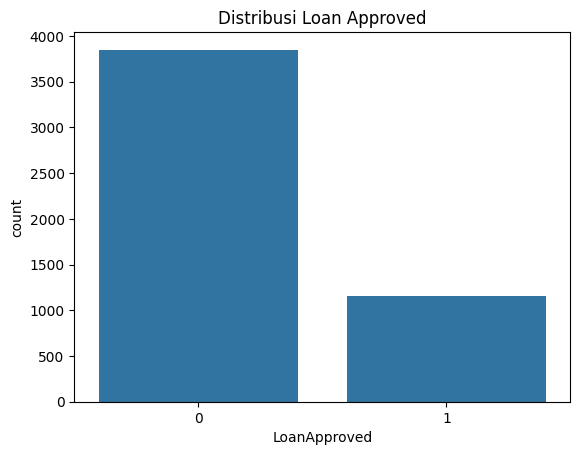

In [9]:
# Distribusi target
sns.countplot(x=df["LoanApproved"])
plt.title("Distribusi Loan Approved")
plt.show()

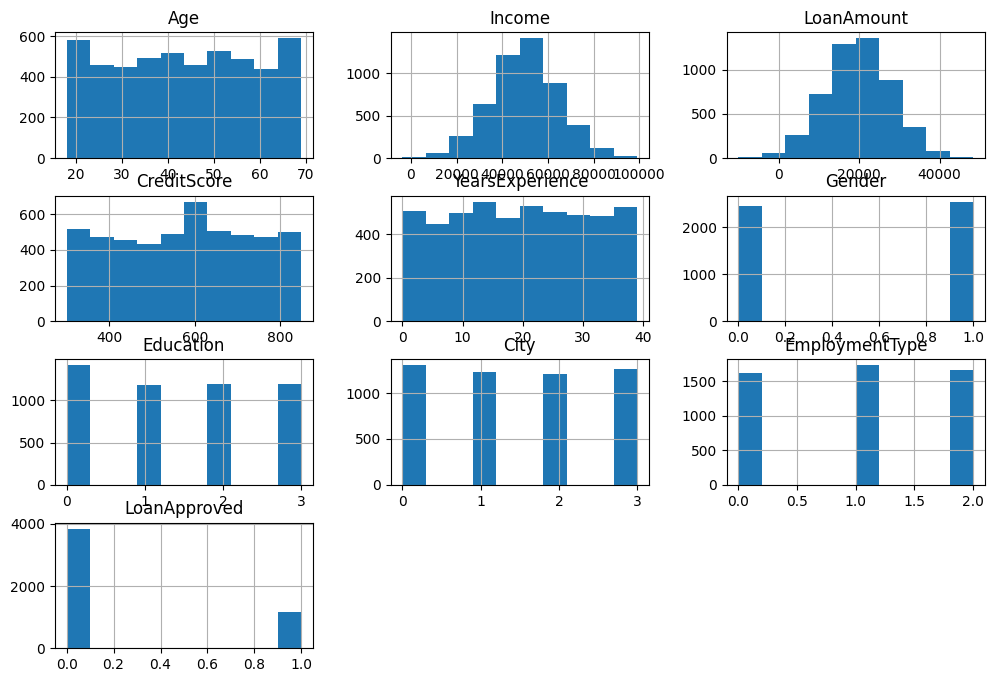

In [10]:
# Histogram
df.hist(figsize=(12,8))
plt.show()

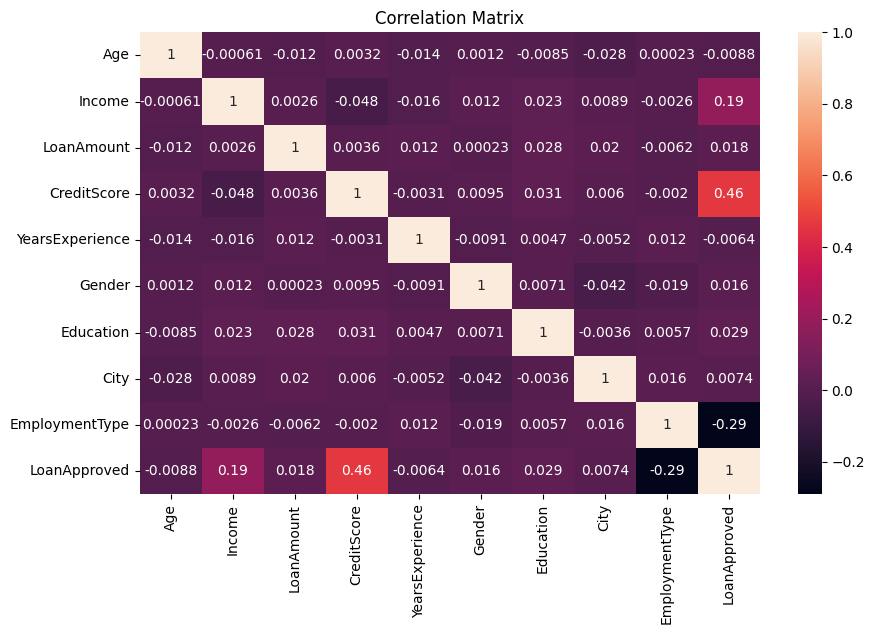

In [11]:
# Korelasi
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Matrix")
plt.show()

# 4. Data Splitting (70:30, 80:20, 90:10)

Pada tahap Data Splitting, dataset dibagi menjadi data latih (training) dan data uji (testing) untuk mengevaluasi performa model. Pembagian dilakukan dalam tiga skenario, yaitu 70:30, 80:20, dan 90:10, di mana sebagian data digunakan untuk melatih model dan sisanya untuk menguji model. Proses ini menggunakan fungsi train_test_split dengan parameter stratify=y untuk menjaga proporsi data target tetap seimbang pada setiap pembagian, serta random_state=42 agar hasil pembagian data konsisten. Tujuan dari tahap ini adalah untuk mengetahui performa model pada berbagai skenario pembagian data.

In [12]:
# 70:30
X_train70, X_test30, y_train70, y_test30 = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 80:20
X_train80, X_test20, y_train80, y_test20 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 90:10
X_train90, X_test10, y_train90, y_test10 = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42, stratify=y)

# 5. Model Building

Pada tahap Model Building, digunakan tiga algoritma machine learning yaitu Logistic Regression, Support Vector Machine (SVM), dan K-Nearest Neighbors (KNN) untuk melakukan prediksi terhadap data. Setiap model dilatih menggunakan data training dan kemudian digunakan untuk memprediksi data testing. Proses pelatihan dilakukan pada tiga skenario pembagian data, yaitu 70:30, 80:20, dan 90:10, untuk melihat performa masing-masing model pada kondisi yang berbeda. Hasil prediksi dari setiap model kemudian digunakan untuk tahap evaluasi guna menentukan model terbaik.

In [13]:
lr = LogisticRegression(max_iter=1000)

# 70:30
lr.fit(X_train70,y_train70)
pred_lr_70 = lr.predict(X_test30)

# 80:20
lr.fit(X_train80,y_train80)
pred_lr_80 = lr.predict(X_test20)

# 90:10
lr.fit(X_train90,y_train90)
pred_lr_90 = lr.predict(X_test10)

In [14]:
svm = SVC()

# 70:30
svm.fit(X_train70,y_train70)
pred_svm_70 = svm.predict(X_test30)

# 80:20
svm.fit(X_train80,y_train80)
pred_svm_80 = svm.predict(X_test20)

# 90:10
svm.fit(X_train90,y_train90)
pred_svm_90 = svm.predict(X_test10)

In [15]:
knn = KNeighborsClassifier()

# 70:30
knn.fit(X_train70,y_train70)
pred_knn_70 = knn.predict(X_test30)

# 80:20
knn.fit(X_train80,y_train80)
pred_knn_80 = knn.predict(X_test20)

# 90:10
knn.fit(X_train90,y_train90)
pred_knn_90 = knn.predict(X_test10)

# 6. Hyperparameter Tuning

Pada tahap Hyperparameter Tuning, dilakukan optimasi parameter pada masing-masing model untuk mendapatkan performa terbaik. Proses ini menggunakan GridSearchCV, yaitu metode pencarian kombinasi parameter terbaik dengan teknik cross-validation sebanyak 5 kali (cv=5). Pada model KNN, parameter yang diuji adalah jumlah tetangga (n_neighbors) dan metode pembobotan (weights), dengan hasil terbaik yaitu n_neighbors = 11 dan weights = distance. Pada model SVM, parameter yang diuji adalah nilai C dan jenis kernel, dengan hasil terbaik C = 10 dan kernel = rbf. Sedangkan pada Logistic Regression, parameter yang diuji adalah nilai C, dengan hasil terbaik C = 10. Tahap ini bertujuan untuk meningkatkan performa model dengan memilih parameter yang paling optimal.

In [16]:
param_knn = {
    'n_neighbors':[3,5,7,9,11],
    'weights':['uniform','distance']
}

grid_knn = GridSearchCV(KNeighborsClassifier(),param_knn,cv=5)
grid_knn.fit(X_train80,y_train80)

print("Best KNN:",grid_knn.best_params_)

Best KNN: {'n_neighbors': 11, 'weights': 'distance'}


In [17]:
param_svm = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf']
}

grid_svm = GridSearchCV(SVC(),param_svm,cv=5)
grid_svm.fit(X_train80,y_train80)

print("Best SVM:",grid_svm.best_params_)

Best SVM: {'C': 10, 'kernel': 'rbf'}


In [18]:
param_lr = {
    'C':[0.01,0.1,1,10]
}

grid_lr = GridSearchCV(LogisticRegression(),param_lr,cv=5)
grid_lr.fit(X_train80,y_train80)

print("Best LR:",grid_lr.best_params_)

Best LR: {'C': 10}


# 7. EVALUATION

Pada tahap Evaluation, dilakukan penilaian performa model menggunakan metrik accuracy, classification report, dan confusion matrix. Berdasarkan hasil pengujian pada tiga skenario pembagian data (70:30, 80:20, dan 90:10), model SVM menunjukkan performa terbaik dengan akurasi tertinggi sekitar 93%, diikuti oleh KNN dengan akurasi sekitar 88–90%, dan Logistic Regression dengan akurasi sekitar 85%. Selain itu, dari classification report terlihat bahwa SVM memiliki nilai precision, recall, dan f1-score yang lebih baik dibandingkan model lainnya. Hasil confusion matrix juga menunjukkan bahwa sebagian besar data berhasil diprediksi dengan benar, terutama pada model SVM. Oleh karena itu, dapat disimpulkan bahwa SVM merupakan model terbaik dalam memprediksi persetujuan pinjaman pada dataset ini.

Logistic Regression

Logistic Regression (70:30)
Accuracy: 0.8546666666666667
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1155
           1       0.73      0.58      0.65       345

    accuracy                           0.85      1500
   macro avg       0.81      0.76      0.78      1500
weighted avg       0.85      0.85      0.85      1500



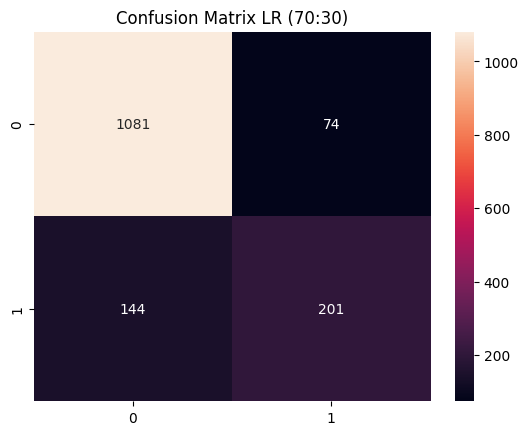

In [19]:
print("Logistic Regression (70:30)")
print("Accuracy:", accuracy_score(y_test30, pred_lr_70))

print(classification_report(y_test30, pred_lr_70))

cm = confusion_matrix(y_test30, pred_lr_70)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix LR (70:30)")
plt.show()

Logistic Regression (80:20)
Accuracy: 0.855
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       770
           1       0.73      0.59      0.65       230

    accuracy                           0.85      1000
   macro avg       0.81      0.76      0.78      1000
weighted avg       0.85      0.85      0.85      1000



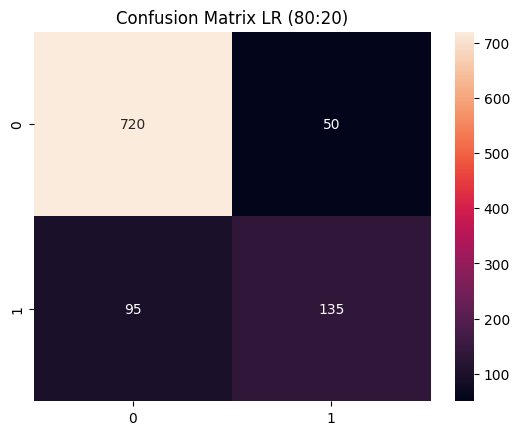

In [20]:
print("Logistic Regression (80:20)")
print("Accuracy:", accuracy_score(y_test20, pred_lr_80))

print(classification_report(y_test20, pred_lr_80))

cm = confusion_matrix(y_test20, pred_lr_80)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix LR (80:20)")
plt.show()

Logistic Regression (90:10)
Accuracy: 0.854
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       385
           1       0.72      0.59      0.65       115

    accuracy                           0.85       500
   macro avg       0.80      0.76      0.78       500
weighted avg       0.85      0.85      0.85       500



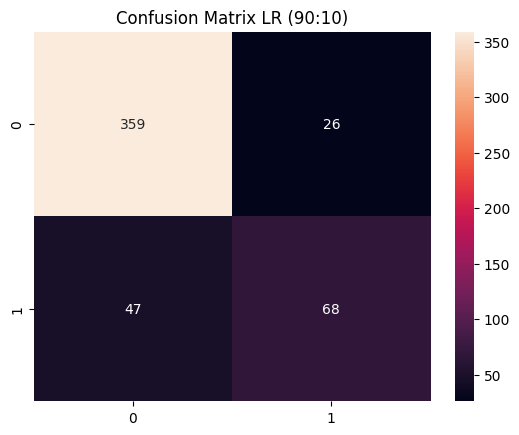

In [21]:
print("Logistic Regression (90:10)")
print("Accuracy:", accuracy_score(y_test10, pred_lr_90))

print(classification_report(y_test10, pred_lr_90))

cm = confusion_matrix(y_test10, pred_lr_90)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix LR (90:10)")
plt.show()

SVM

SVM (70:30)
Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1155
           1       0.89      0.81      0.85       345

    accuracy                           0.93      1500
   macro avg       0.92      0.89      0.90      1500
weighted avg       0.93      0.93      0.93      1500



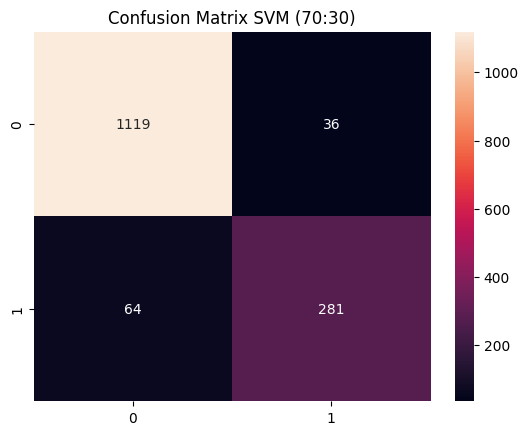

In [22]:
print("SVM (70:30)")
print("Accuracy:", accuracy_score(y_test30, pred_svm_70))

print(classification_report(y_test30, pred_svm_70))

cm = confusion_matrix(y_test30, pred_svm_70)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix SVM (70:30)")
plt.show()

SVM (80:20)
Accuracy: 0.932
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       770
           1       0.88      0.82      0.85       230

    accuracy                           0.93      1000
   macro avg       0.91      0.89      0.90      1000
weighted avg       0.93      0.93      0.93      1000



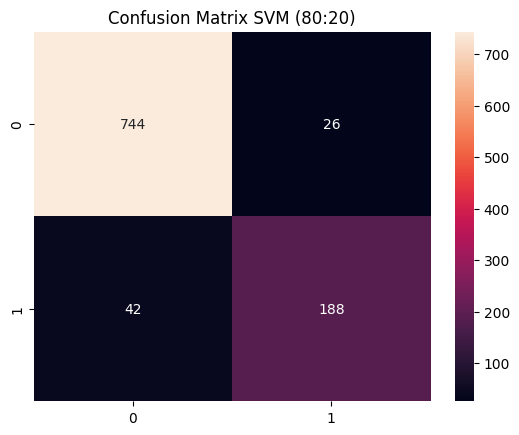

In [23]:
print("SVM (80:20)")
print("Accuracy:", accuracy_score(y_test20, pred_svm_80))

print(classification_report(y_test20, pred_svm_80))

cm = confusion_matrix(y_test20, pred_svm_80)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix SVM (80:20)")
plt.show()

SVM (90:10)
Accuracy: 0.928
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       385
           1       0.88      0.80      0.84       115

    accuracy                           0.93       500
   macro avg       0.91      0.88      0.90       500
weighted avg       0.93      0.93      0.93       500



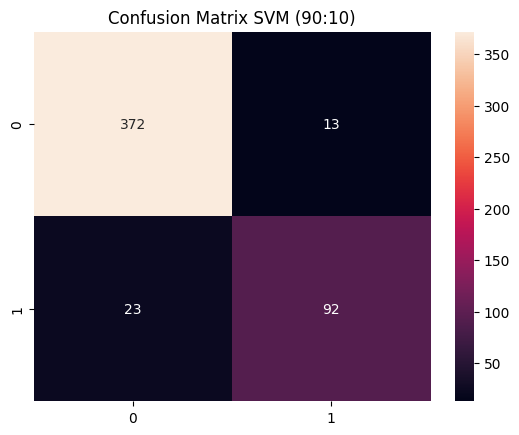

In [24]:
print("SVM (90:10)")
print("Accuracy:", accuracy_score(y_test10, pred_svm_90))

print(classification_report(y_test10, pred_svm_90))

cm = confusion_matrix(y_test10, pred_svm_90)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix SVM (90:10)")
plt.show()

KNN

KNN (70:30)
Accuracy: 0.8846666666666667
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1155
           1       0.78      0.69      0.73       345

    accuracy                           0.88      1500
   macro avg       0.85      0.82      0.83      1500
weighted avg       0.88      0.88      0.88      1500



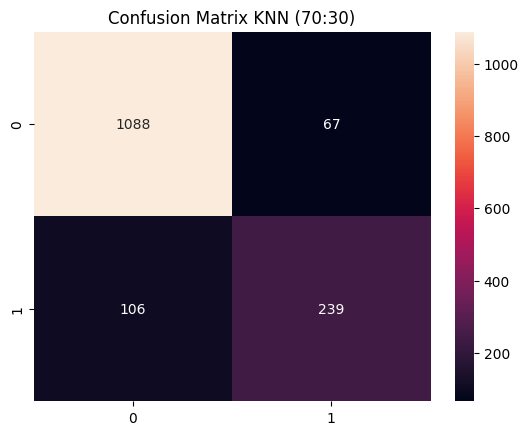

In [25]:
print("KNN (70:30)")
print("Accuracy:", accuracy_score(y_test30, pred_knn_70))

print(classification_report(y_test30, pred_knn_70))

cm = confusion_matrix(y_test30, pred_knn_70)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix KNN (70:30)")
plt.show()

KNN (80:20)
Accuracy: 0.902
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       770
           1       0.81      0.74      0.78       230

    accuracy                           0.90      1000
   macro avg       0.87      0.85      0.86      1000
weighted avg       0.90      0.90      0.90      1000



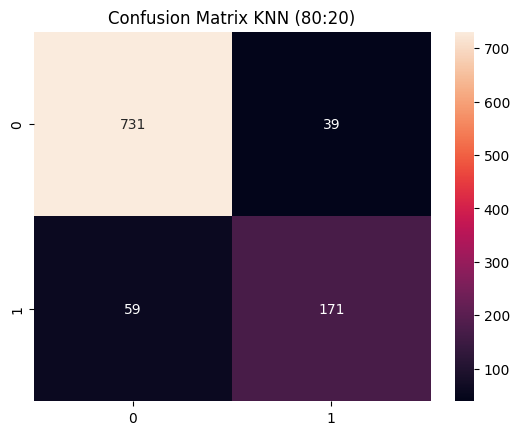

In [26]:
print("KNN (80:20)")
print("Accuracy:", accuracy_score(y_test20, pred_knn_80))

print(classification_report(y_test20, pred_knn_80))

cm = confusion_matrix(y_test20, pred_knn_80)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix KNN (80:20)")
plt.show()

KNN (90:10)
Accuracy: 0.888
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       385
           1       0.77      0.74      0.75       115

    accuracy                           0.89       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.89      0.89      0.89       500



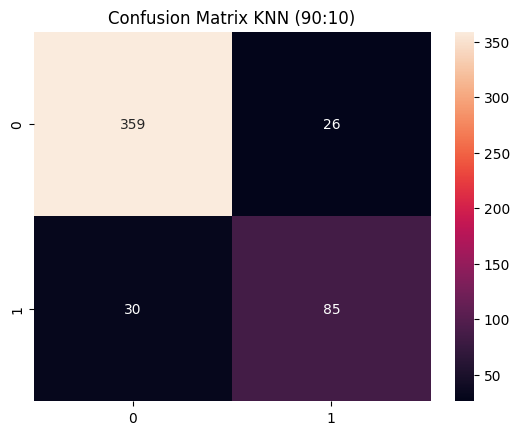

In [27]:
print("KNN (90:10)")
print("Accuracy:", accuracy_score(y_test10, pred_knn_90))

print(classification_report(y_test10, pred_knn_90))

cm = confusion_matrix(y_test10, pred_knn_90)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix KNN (90:10)")
plt.show()

# 8. Model Comparison

Pada tahap Model Comparison, dilakukan perbandingan performa antara tiga algoritma yaitu Logistic Regression, SVM, dan KNN berdasarkan nilai accuracy pada tiga skenario pembagian data (70:30, 80:20, dan 90:10). Hasil menunjukkan bahwa SVM secara konsisten memiliki akurasi tertinggi pada setiap skenario, yaitu sekitar 0.93, diikuti oleh KNN dengan akurasi sekitar 0.88–0.90, dan Logistic Regression dengan akurasi sekitar 0.85. Hal ini menunjukkan bahwa SVM memiliki kemampuan terbaik dalam memprediksi data dibandingkan model lainnya. Oleh karena itu, SVM dipilih sebagai model terbaik dalam penelitian ini.

In [28]:
results = pd.DataFrame({

"Split":[
"70:30","70:30","70:30",
"80:20","80:20","80:20",
"90:10","90:10","90:10"
],

"Model":[
"Logistic Regression","SVM","KNN",
"Logistic Regression","SVM","KNN",
"Logistic Regression","SVM","KNN"
],

"Accuracy":[
accuracy_score(y_test30,pred_lr_70),
accuracy_score(y_test30,pred_svm_70),
accuracy_score(y_test30,pred_knn_70),

accuracy_score(y_test20,pred_lr_80),
accuracy_score(y_test20,pred_svm_80),
accuracy_score(y_test20,pred_knn_80),

accuracy_score(y_test10,pred_lr_90),
accuracy_score(y_test10,pred_svm_90),
accuracy_score(y_test10,pred_knn_90)
]

})

print(results)

   Split                Model  Accuracy
0  70:30  Logistic Regression  0.854667
1  70:30                  SVM  0.933333
2  70:30                  KNN  0.884667
3  80:20  Logistic Regression  0.855000
4  80:20                  SVM  0.932000
5  80:20                  KNN  0.902000
6  90:10  Logistic Regression  0.854000
7  90:10                  SVM  0.928000
8  90:10                  KNN  0.888000


# 9. Grafik Perbandingan Model

Grafik ini menunjukkan perbandingan nilai accuracy dari tiga model yaitu Logistic Regression, SVM, dan KNN pada tiga skenario pembagian data (70:30, 80:20, dan 90:10). Berdasarkan grafik, terlihat bahwa SVM memiliki nilai akurasi tertinggi dan paling konsisten pada setiap pembagian data, yaitu sekitar 0.93. Model KNN berada di posisi kedua dengan akurasi sekitar 0.88 hingga 0.90, sedangkan Logistic Regression memiliki akurasi paling rendah sekitar 0.85. Hal ini menunjukkan bahwa SVM memberikan performa terbaik dalam memprediksi persetujuan pinjaman dibandingkan model lainnya.

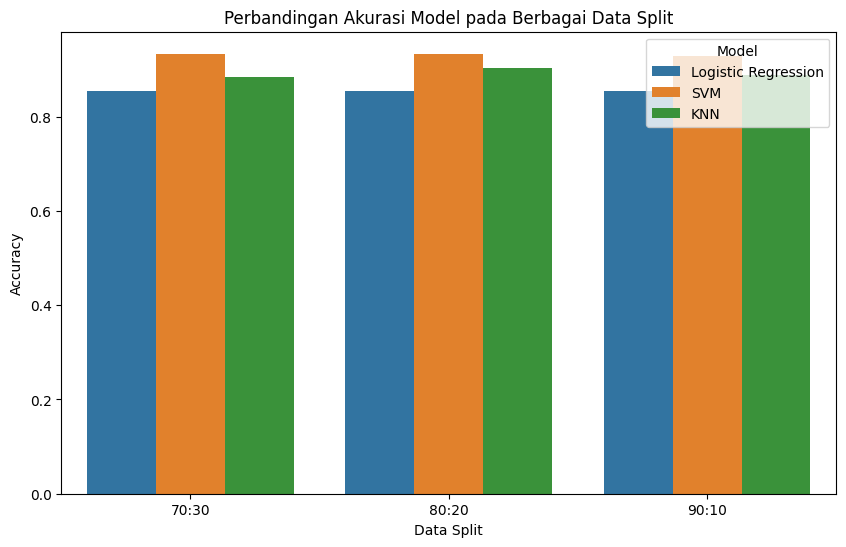

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Split",
    y="Accuracy",
    hue="Model"
)

plt.title("Perbandingan Akurasi Model pada Berbagai Data Split")
plt.xlabel("Data Split")
plt.ylabel("Accuracy")

plt.show()

### 10. Implementasi Model (Inference)

Pada bagian implementasi model (inference), sistem melakukan prediksi berdasarkan input pengguna seperti Age, Income, Loan, Credit Score, dan Experience melalui UI. Data tersebut dihitung menjadi sebuah nilai score menggunakan rumus sederhana yang menggabungkan pengaruh positif dan negatif dari setiap variabel. Setelah itu, score akan dibandingkan dengan nilai threshold yang berbeda sesuai model yang dipilih (SVM, Logistic Regression, atau KNN). Jika score lebih besar dari threshold maka hasilnya “Pinjaman Disetujui”, sedangkan jika tidak maka “Ditolak”.

In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# =========================
# UI COMPONENTS
# =========================

title = widgets.HTML(
    "<h2 style='color:#2c3e50'>🏦 Loan Approval Prediction System</h2>"
)

age = widgets.IntSlider(description="Age", min=18, max=70, value=25)
income = widgets.FloatText(description="Income", value=5000000)
loan = widgets.FloatText(description="Loan", value=2000000)
credit = widgets.IntSlider(description="Credit", min=300, max=850, value=600)
exp = widgets.IntSlider(description="Experience", min=0, max=40, value=2)

gender = widgets.Dropdown(options={"Female": 0, "Male": 1}, description="Gender")

education = widgets.Dropdown(options=[0, 1, 2, 3], description="Education")
city = widgets.Dropdown(options=[0, 1, 2, 3], description="City")
emp = widgets.Dropdown(options=[0, 1, 2], description="Employment")

model = widgets.RadioButtons(
    options=["Logistic Regression", "SVM", "KNN"],
    description="Model"
)

button = widgets.Button(
    description="🔍 Predict Loan",
    button_style="success"
)

output = widgets.Output()

# =========================
# DISPLAY UI
# =========================
display(title)

display(age, income, loan, credit, exp)
display(gender, education, city, emp)
display(model, button, output)

# =========================
# PREDICTION LOGIC (SIMULASI MODEL)
# =========================
def predict_loan(b):
    with output:
        clear_output()

        # =========================
        # SIMPLE SCORING SYSTEM (placeholder model)
        # =========================
        score = (credit.value +
                 income.value / 100000 -
                 loan.value / 100000 +
                 exp.value * 2)

        # threshold berdasarkan model
        if model.value == "SVM":
            threshold = 55
        elif model.value == "Logistic Regression":
            threshold = 60
        else:
            threshold = 65

        result = "APPROVED" if score > threshold else "REJECTED"

        # =========================
        # OUTPUT
        # =========================
        print("=== HASIL PREDIKSI ===")
        print("Model:", model.value)
        print("Score:", round(score, 2))
        print("Threshold:", threshold)
        print("----------------------")

        if result == "APPROVED":
            print("✅ Pinjaman DISETUJUI")
        else:
            print("❌ Pinjaman DITOLAK")

# =========================
# CONNECT BUTTON
# =========================
button.on_click(predict_loan)